In [7]:
import os
os.listdir('../data/')

['MM-dataset description.pdf', '7wpcv7kp6f-1.zip', 'MM-DataSet.arff']

In [9]:
import pandas as pd
from scipy.io import arff
import io

# Leer el archivo como texto y limpiar espacios
with open('../data/MM-DataSet.arff', 'r') as f:
    content = f.read()

# Cargar con arff
data, meta = arff.loadarff(io.StringIO(content.replace(' ,', ',').replace(', ', ',').strip()))

# Convertir a DataFrame
df = pd.DataFrame(data)

# Decodificar columnas de texto (ARFF las carga como bytes)
str_cols = df.select_dtypes(include=['object']).columns
df[str_cols] = df[str_cols].apply(lambda x: x.str.decode('utf-8').str.strip())

print(df.shape)
df.head()

(203, 59)


,wilaya,gender,age,body_surf,weight,married,nbrs_child,blood,HBP,diabete,...,HIV,Ag_HBS,gly,TCA,TP,Fib,Ferr,LDH,FE,CLASS
0,Tlemcen,0,74.0,1.76,68.0,1,8.0,?,0,0,...,?,?,1.09,NaN,NaN,NaN,NaN,201.0,69.0,6
1,Tlemcen,1,67.0,1.63,59.0,1,6.0,O+,0,0,...,0,0,0.96,34.1,77.3,2.71,NaN,327.0,65.0,6
2,Tlemcen,1,88.0,1.47,50.0,1,9.0,O+,1,0,...,0,0,0.73,NaN,NaN,NaN,NaN,349.5,NaN,6
3,SidiBelabes,1,63.0,NaN,65.0,?,NaN,O+,1,1,...,0,0,1.07,33.2,100.0,4.20,346.9,441.6,60.0,6
4,Tlemcen,0,53.0,NaN,NaN,1,5.0,A+,0,0,...,0,0,1.18,13.0,100.0,5.84,NaN,209.0,74.0,4


In [10]:
print("=== SHAPE ===")
print(df.shape)

print("\n=== DATA TYPES ===")
print(df.dtypes)

print("\n=== NULL VALUES ===")
print(df.isnull().sum().sort_values(ascending=False))

print("\n=== TARGET DISTRIBUTION ===")
print(df['CLASS'].value_counts())

=== SHAPE ===
(203, 59)

=== DATA TYPES ===
wilaya            object
gender            object
age              float64
body_surf        float64
weight           float64
married           object
nbrs_child       float64
blood             object
HBP               object
diabete           object
tobacco           object
chron_disea       object
hrd_blo_disea     object
asth&bone         object
anemia            object
CBC_WBC          float64
CBC_RBC          float64
CBC_plats        float64
CBC_Hgb          float64
CBC_Hct          float64
CBC_MCV          float64
CBC_MCHC         float64
VS               float64
roll_RBC          object
plasma_cells     float64
Ca               float64
K                float64
P                float64
Na               float64
B2M              float64
CRP               object
creat            float64
Urea             float64
clair_creat      float64
24h_prot          object
BJp               object
alb              float64
a_glob           float64
B_glob

In [21]:
# Official class mapping based on dataset documentation (Guilal et al., University of Tlemcen)
# Durie-Salmon Classification + International Staging System
class_mapping = {
    '0': 'MGUS',    # Monoclonal gammopathy of undetermined significance
    '1': 'ASYM',    # Asymptomatic Myeloma (Smoldering)
    '2': 'IA',      # Stage I type A (creatinine < 20 mg/l)
    '3': 'IB',      # Stage I type B (creatinine > 20 mg/l)
    '4': 'IIA',     # Stage II type A
    '5': 'IIB',     # Stage II type B
    '6': 'IIIA',    # Stage III type A — majority class
    '7': 'IIIB',    # Stage III type B
    '8': 'PLASMO'   # Plasmacytoma
}

df['CLASS_LABEL'] = df['CLASS'].map(class_mapping)

print("=== CLASS DISTRIBUTION ===\n")
for label, count in df['CLASS_LABEL'].value_counts().items():
    pct = count/len(df)*100
    print(f"  {label:8} → {count:3} patients ({pct:.1f}%)")

print(f"\n⚠️  Highly imbalanced dataset: IIIA accounts for {df[df['CLASS_LABEL']=='IIIA'].shape[0]/len(df)*100:.1f}% of total samples")

=== CLASS DISTRIBUTION ===

  IIIA     → 108 patients (53.2%)
  IIIB     →  37 patients (18.2%)
  IA       →  22 patients (10.8%)
  IIA      →  19 patients (9.4%)
  MGUS     →   6 patients (3.0%)
  ASYM     →   5 patients (2.5%)
  IB       →   3 patients (1.5%)
  PLASMO   →   2 patients (1.0%)
  IIB      →   1 patients (0.5%)

⚠️  Highly imbalanced dataset: IIIA accounts for 53.2% of total samples


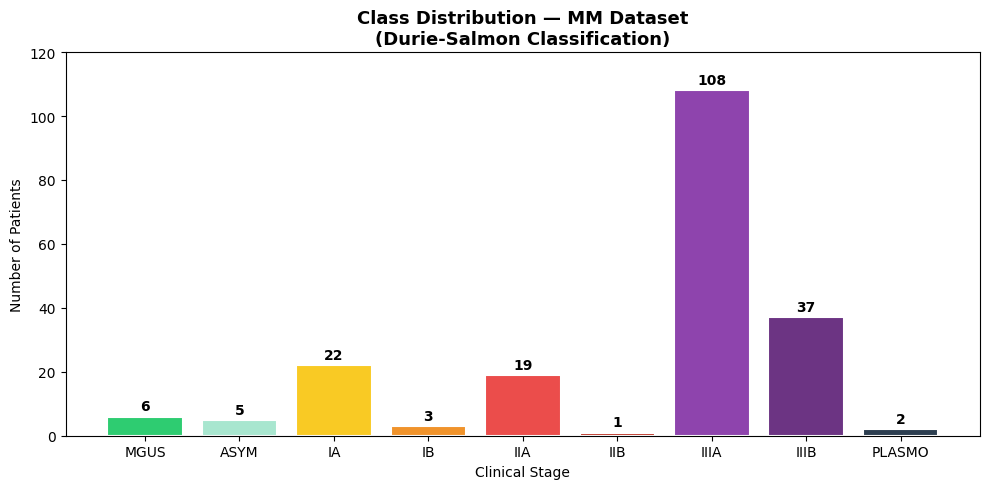

In [20]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Colors by clinical severity
colors = {
    'MGUS': '#2ecc71',    # green - precancerous
    'ASYM': '#a8e6cf',    # light green - asymptomatic
    'IA':   '#f9ca24',    # yellow - stage I
    'IB':   '#f0932b',    # orange
    'IIA':  '#eb4d4b',    # light red - stage II
    'IIB':  '#c0392b',    # red
    'IIIA': '#8e44ad',    # purple - stage III
    'IIIB': '#6c3483',    # dark purple
    'PLASMO': '#2c3e50'   # dark - plasmacytoma
}

order = ['MGUS','ASYM','IA','IB','IIA','IIB','IIIA','IIIB','PLASMO']
counts = [df[df['CLASS_LABEL']==c].shape[0] for c in order]
bar_colors = [colors[c] for c in order]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(order, counts, color=bar_colors, edgecolor='white', linewidth=1.5)

for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(count), ha='center', va='bottom', fontweight='bold')

ax.set_title('Class Distribution — MM Dataset\n(Durie-Salmon Classification)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Clinical Stage')
ax.set_ylabel('Number of Patients')
ax.set_ylim(0, 120)
plt.tight_layout()
plt.savefig('../notebooks/class_distribution.png', dpi=150)
plt.show()

In [18]:
# Concordance between Multiple Myeloma classification systems
concordance = {
    'Durie-Salmon Classification': ['MGUS', 'ASYM (SMM)', 'IA', 'IB', 'IIA', 'IIB', 'IIIA', 'IIIB', 'PLASMO'],
    'Clinical Progression':        ['MGUS', 'SMM', 'Active MM', 'Active MM', 'Active MM', 'Active MM', 'Active MM', 'Active MM', 'Active MM'],
    'Modeling Group':              ['Excluded*', 'Excluded*', 'Stage I', 'Stage I', 'Stage II', 'Stage II', 'Stage III', 'Stage III', 'Excluded*'],
    'N patients':                  [6, 5, 22, 3, 19, 1, 108, 37, 2]
}

df_concordance = pd.DataFrame(concordance)
print("=== CONCORDANCE BETWEEN CLASSIFICATION SYSTEMS ===\n")
print(df_concordance.to_string(index=False))
print("\n* Excluded from main modeling due to insufficient sample size")
print(f"  Patients included in modeling: {22+3+19+1+108+37} / {len(df)}")
print(f"  Patients excluded: {6+5+2} / {len(df)}")


=== CONCORDANCE BETWEEN CLASSIFICATION SYSTEMS ===

Durie-Salmon Classification Clinical Progression Modeling Group  N patients
                       MGUS                 MGUS      Excluded*           6
                 ASYM (SMM)                  SMM      Excluded*           5
                         IA            Active MM        Stage I          22
                         IB            Active MM        Stage I           3
                        IIA            Active MM       Stage II          19
                        IIB            Active MM       Stage II           1
                       IIIA            Active MM      Stage III         108
                       IIIB            Active MM      Stage III          37
                     PLASMO            Active MM      Excluded*           2

* Excluded from main modeling due to insufficient sample size
  Patients included in modeling: 190 / 203
  Patients excluded: 13 / 203
